In [210]:
import pandas as pd

In [211]:
#!pip install scikit-learn
import sklearn
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [212]:
import numpy as np
np.set_printoptions(linewidth=np.inf)

data_read = pd.read_csv('/content/sample_data/X.csv')
data = data_read.iloc[:,:5].values

In [215]:
data

array([[  2.99086734,   2.35834988,  -6.87392711,   1.92623249,  -4.65594848],
       [ -0.82224511,  -7.30168551,  -6.41254237,   7.30733686,   7.7727851 ],
       [ 14.00206488,  -0.11233668, -12.9377653 , -12.65721449,  -8.29891706],
       ...,
       [  0.85329277,  -9.38342299,  -5.98134118,   8.20625752,   8.50950942],
       [  1.92082569,   5.19235627,  -8.94678622,   4.23735173,  -5.20844974],
       [  5.46236004,   8.45209339,  -9.35059184,   0.99628101,  -5.35694092]])

In [216]:
#https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
Sum_of_squared_distances = []
K = range(1,11)
for num_clusters in K :
 kmeans = KMeans(n_clusters=num_clusters,n_init=11,random_state=42)
 kmeans.fit(data)
 Sum_of_squared_distances.append(kmeans.inertia_)
 print(f"Inertias of K = {num_clusters}:  {kmeans.inertia_}")

print(f"Inertias of K = 1 to 10:  {Sum_of_squared_distances}")

Inertias of K = 1:  73229.11237791988
Inertias of K = 2:  45654.15661661549
Inertias of K = 3:  30634.967624559507
Inertias of K = 4:  22146.85530759386
Inertias of K = 5:  19609.37682647738
Inertias of K = 6:  18153.849660519
Inertias of K = 7:  16706.161806646873
Inertias of K = 8:  15598.00671135122
Inertias of K = 9:  14956.8017013365
Inertias of K = 10:  14265.705433706162
Inertias of K = 1 to 10:  [73229.11237791988, 45654.15661661549, 30634.967624559507, 22146.85530759386, 19609.37682647738, 18153.849660519, 16706.161806646873, 15598.00671135122, 14956.8017013365, 14265.705433706162]


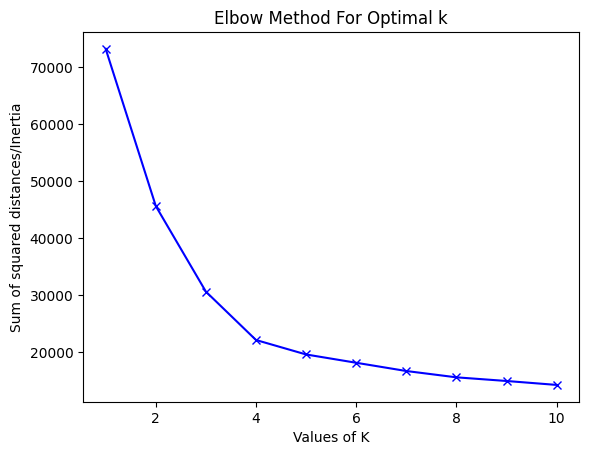

In [217]:
plt.plot(K,Sum_of_squared_distances,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Sum of squared distances/Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [218]:
from kneed import KneeLocator

knee_locator = KneeLocator(K, Sum_of_squared_distances, curve="convex", direction="decreasing")
optimal_k = knee_locator.elbow
print(f"Optimal K จาก KneeLocator คือ: {optimal_k}")

Optimal K จาก KneeLocator คือ: 4


In [219]:
# n_int is to set max no. of clusters
cluster = KMeans(n_clusters=optimal_k).fit(data)
print(cluster.cluster_centers_)
print(cluster.labels_)

[[ 2.79311744  6.92268313 -5.90449043 -0.65748703 -5.03618127]
 [-0.18283883 -7.87359892 -5.30449108  7.72989529  7.86089087]
 [-6.92265575  2.94321791 -7.98161349  0.46542238  3.57593848]
 [ 5.53032858 -1.57257033 -3.04691233 -6.15273254  1.06736159]]
[0 1 3 2 3 2 0 0 3 0 1 1 0 2 1 2 1 0 0 1 1 3 2 1 2 2 1 3 2 2 1 2 3 3 3 3 0 0 2 1 3 0 2 1 0 2 2 0 2 3 2 3 0 0 3 2 1 0 0 0 1 2 0 0 2 2 1 0 0 2 0 0 2 0 3 2 0 1 3 1 0 1 3 1 1 3 3 3 3 3 2 2 2 2 2 0 2 3 1 2 3 0 1 1 1 3 2 0 0 2 0 2 0 3 1 2 2 1 1 1 0 1 1 0 2 3 2 1 2 0 3 1 1 2 0 2 0 3 2 1 0 1 1 2 1 1 0 1 0 2 1 0 3 0 0 0 2 1 2 3 0 2 3 1 1 2 2 2 0 0 1 3 0 1 1 1 2 2 1 0 1 2 3 3 1 1 1 0 2 1 1 1 1 3 3 0 2 0 0 0 0 2 2 3 0 0 0 2 2 1 1 0 1 1 2 0 1 3 2 2 2 1 0 2 2 2 2 0 2 2 2 1 2 3 0 0 1 0 0 1 3 1 1 1 0 0 2 2 0 3 3 0 0 2 2 0 1 1 1 2 1 3 3 1 0 1 1 3 2 3 2 2 1 2 1 3 0 0 0 3 0 0 2 0 1 0 2 0 2 3 0 2 1 1 2 3 0 0 0 0 3 2 2 0 2 3 0 2 1 1 3 3 0 1 2 0 1 1 0 3 3 1 0 1 3 1 3 2 3 1 1 0 3 0 3 2 1 2 0 0 0 1 3 0 2 0 3 0 3 0 1 3 2 0 3 3 0 3 2 3 1 0 2 0 0 2 0 2 3 3 1 1 2 

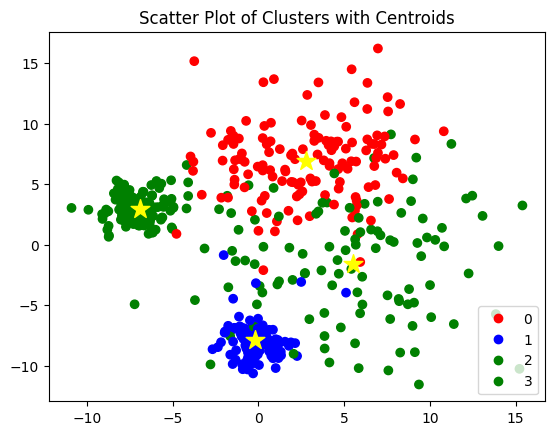

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

colours = ListedColormap(['r', 'b', 'g'])

scatter = plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap=colours)
plt.scatter(cluster.cluster_centers_[:,0], cluster.cluster_centers_[:,1],
            c='yellow', marker='*', s=200, label='Centroids')

plt.legend(*scatter.legend_elements(), loc="lower right")
plt.title('Scatter Plot of Clusters with Centroids')

plt.show()


In [221]:
cluster_representatives_df = pd.read_csv('/content/sample_data/cluster_representatives.csv')

cluster_representatives = cluster_representatives_df.values

print(cluster_representatives_df.head())


          0         1         2         3         4
0  7.400497  7.111488 -7.359816 -4.954649 -8.641022
1 -0.761696 -8.315184 -6.561970  8.338585  6.597992
2 -7.791947  2.635877 -7.353285 -1.181368  3.402595
3 -0.216567 -1.605935 -3.762888 -0.317886  1.632656


In [222]:
predict = cluster.predict(cluster_representatives)
print(predict)

[0 1 2 3]


In [223]:
print("Optimal K =", optimal_k,"\n")
print("Centroids ของแต่ละ Cluster:\n", cluster.cluster_centers_,"\n")
print("Class numbers ของข้อมูล:\n", cluster.labels_,"\n")
print("ผลลัพธ์การทำนายคลัสเตอร์ของข้อมูลใหม่:\n", predict)

Optimal K = 4 

Centroids ของแต่ละ Cluster:
 [[ 2.79311744  6.92268313 -5.90449043 -0.65748703 -5.03618127]
 [-0.18283883 -7.87359892 -5.30449108  7.72989529  7.86089087]
 [-6.92265575  2.94321791 -7.98161349  0.46542238  3.57593848]
 [ 5.53032858 -1.57257033 -3.04691233 -6.15273254  1.06736159]] 

Class numbers ของข้อมูล:
 [0 1 3 2 3 2 0 0 3 0 1 1 0 2 1 2 1 0 0 1 1 3 2 1 2 2 1 3 2 2 1 2 3 3 3 3 0 0 2 1 3 0 2 1 0 2 2 0 2 3 2 3 0 0 3 2 1 0 0 0 1 2 0 0 2 2 1 0 0 2 0 0 2 0 3 2 0 1 3 1 0 1 3 1 1 3 3 3 3 3 2 2 2 2 2 0 2 3 1 2 3 0 1 1 1 3 2 0 0 2 0 2 0 3 1 2 2 1 1 1 0 1 1 0 2 3 2 1 2 0 3 1 1 2 0 2 0 3 2 1 0 1 1 2 1 1 0 1 0 2 1 0 3 0 0 0 2 1 2 3 0 2 3 1 1 2 2 2 0 0 1 3 0 1 1 1 2 2 1 0 1 2 3 3 1 1 1 0 2 1 1 1 1 3 3 0 2 0 0 0 0 2 2 3 0 0 0 2 2 1 1 0 1 1 2 0 1 3 2 2 2 1 0 2 2 2 2 0 2 2 2 1 2 3 0 0 1 0 0 1 3 1 1 1 0 0 2 2 0 3 3 0 0 2 2 0 1 1 1 2 1 3 3 1 0 1 1 3 2 3 2 2 1 2 1 3 0 0 0 3 0 0 2 0 1 0 2 0 2 3 0 2 1 1 2 3 0 0 0 0 3 2 2 0 2 3 0 2 1 1 3 3 0 1 2 0 1 1 0 3 3 1 0 1 3 1 3 2 3 1 1 0 3 0 3 2 1